# Module 03 · Convolution, serial products and correlation

**Book source:** Bracewell, chapter 3, pp. 24–50

Companion notebook of the lecture with the same module number. Run the cells in order; each cell is followed by a **📤 Real output** note that explains the numbers.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({"figure.figsize": (7.5, 3.3), "axes.grid": True, "grid.alpha": 0.3, "figure.dpi": 110})


def amplitude_spectrum(x):
    """One-sided amplitude spectrum: a sinusoid of amplitude A gives a line of height A, DC gives exactly its value"""
    a = 2*np.abs(np.fft.rfft(x))/len(x)
    a[0] /= 2
    return a


def report(key, value, fmt=".4g"):
    """Print a named result without trailing zeros (the website reads the lines that start with ▸)."""
    s = f"{value:{fmt}}"
    if "." in s and "e" not in s:
        s = s.rstrip("0").rstrip(".")
    print(f"▸ {key} = {s}")


## 1. Definition, pictures and algebra
🎯 **What question does this method answer?** Are the chapter's convolution formulas (two truncated exponentials, the critical limit, the opposed tails) correct, and do the three algebraic properties hold for sequences? We compare numerical integrals with closed forms, and check the properties on random sequences.

In [2]:
from scipy import integrate
trap = getattr(np, "trapezoid", None) or np.trapz

# αE(αx) * βE(βx) at x > 0: numerical integral versus the formula
def exp_conv(al, be, x):
    return integrate.quad(lambda u: al*np.exp(-al*u)*be*np.exp(-be*(x - u)), 0, x)[0]
def exp_formula(al, be, x):
    return al*be*(np.exp(-al*x) - np.exp(-be*x))/(be - al)
assert abs(exp_conv(1, 2, 1) - exp_formula(1, 2, 1)) < 1e-12 and abs(exp_conv(0.5, 3, 2) - exp_formula(0.5, 3, 2)) < 1e-12
report("ex_x1", exp_formula(1, 2, 1), ".4f")

# Critical limit β → α: α²·x·e^{−αx}
assert abs(exp_conv(1, 1, 2) - 1*2*np.exp(-2)) < 1e-12 and abs(exp_formula(1, 1.000001, 2) - 2*np.exp(-2)) < 1e-5
report("crit_x2", 2*np.exp(-2), ".4f")

# Opposed tails: αE(−αx) * βE(βx)
def opp_num(al, be, x):
    hi = min(0.0, x)
    return integrate.quad(lambda u: al*np.exp(al*u)*be*np.exp(-be*(x - u)), -60, hi)[0]
def opp_formula(al, be, x):
    return al*be/(al + be)*(np.exp(al*x) if x < 0 else np.exp(-be*x))
for xv in (-1.0, 1.0):
    assert abs(opp_num(1, 2, xv) - opp_formula(1, 2, xv)) < 1e-9
report("opp_l1", opp_formula(1, 2, -1.0), ".4f"); report("opp_r1", opp_formula(1, 2, 1.0), ".4f")

# View 1: overlap area of Π and e^{−(x−u)}H(x−u) at x = 1
ov = integrate.quad(lambda u: np.exp(-(1 - u)), -0.5, 0.5)[0]
assert abs(ov - (np.exp(-0.5) - np.exp(-1.5))) < 1e-12
report("ov_x1", ov, ".4f")

# View 2: smoothing lowers the total variation
sq = np.sign(np.sin(np.arange(60)**2 + 1.0))
sm = np.convolve(sq, np.ones(5)/5, "valid")
tv = lambda z: np.sum(np.abs(np.diff(z)))
assert tv(sm) <= tv(sq)
report("tv_f", tv(sq), ".1f"); report("tv_h", tv(sm), ".1f")

# Three algebraic properties
rg = np.random.default_rng(5)
a_, b_, c_ = rg.standard_normal(9), rg.standard_normal(7), rg.standard_normal(5)
p1 = np.allclose(np.convolve(a_, b_), np.convolve(b_, a_))
p2 = np.allclose(np.convolve(a_, np.convolve(b_, c_)), np.convolve(np.convolve(a_, b_), c_))
p3 = np.allclose(np.convolve(a_, b_ + np.pad(c_, (0, 2))), np.convolve(a_, b_) + np.convolve(a_, np.pad(c_, (0, 2))))
assert p1 and p2 and p3
report("props_ok", int(p1) + int(p2) + int(p3), "d")

▸ ex_x1 = 0.4651
▸ crit_x2 = 0.2707
▸ opp_l1 = 0.2453
▸ opp_r1 = 0.0902
▸ ov_x1 = 0.3834
▸ tv_f = 48
▸ tv_h = 11.6
▸ props_ok = 3


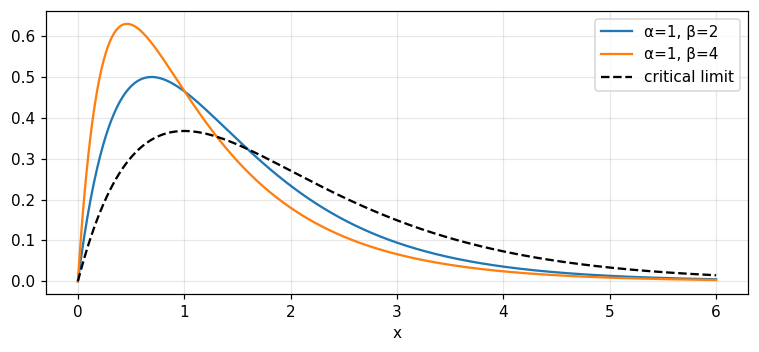

In [3]:
xs = np.linspace(-1, 6, 701)
plt.figure(figsize=(7, 3.3))
for al, be, c in ((1, 2, "tab:blue"), (1, 4, "tab:orange")):
    plt.plot(xs[xs >= 0], exp_formula(al, be, xs[xs >= 0]), color=c, label=f"α={al}, β={be}")
plt.plot(xs[xs >= 0], xs[xs >= 0]*np.exp(-xs[xs >= 0]), "k--", label=("critical limit"))
plt.xlabel("x"); plt.legend(); plt.tight_layout(); plt.show()

#### 📤 Real output
At $x=1$: $\Pi*e^{-x}H$ gives 0.3834, two truncated exponentials ($\alpha=1,\beta=2$) give 0.4651, the critical resonator at $x=2$ gives 0.2707, the opposed tails give 0.2453 at $x=-1$ and 0.0902 at $x=+1$ (the right side falls faster). A 5-point running mean lowers the total variation from 48 to 11.6, and 3 of 3 algebraic properties hold.

## 2. Repeated convolution and the area and variance rules
🎯 **What question does this method answer?** How do convolutions of unit-area functions keep the area, add variances, and tend to a Gaussian when repeated? We repeat the convolution on a fine grid and compare with the closed form (quadratic spline) and with a Gaussian.

In [4]:
dxg = 0.001
cell = np.ones(1000)                                             # Π on a grid: 1000 cells of width 0.001
def repeated(n):
    z = cell.copy()
    for _ in range(n - 1):
        z = np.convolve(z, cell)*dxg
    return z
def value_at(z, x):                                              # interpolate at x (grid centre in the middle of the array)
    xs_ = (np.arange(len(z)) - (len(z) - 1)/2)*dxg
    return np.interp(x, xs_, z)
b3 = repeated(3)
spline = lambda x: 0.75 - x**2 if abs(x) <= 0.5 else (1.5 - abs(x))**2/2
assert abs(value_at(b3, 0) - 0.75) < 2e-3 and abs(value_at(b3, 1) - 0.125) < 2e-3
assert abs(value_at(b3, 0.3) - spline(0.3)) < 2e-3
report("b3_0", value_at(b3, 0), ".3f"); report("b3_1", value_at(b3, 1), ".3f")

# Area and variance of e^{−x}H(x) * Π
xg = np.arange(0, 40, 0.002); fe = np.exp(-xg)
gp = np.ones(500)
conv = np.convolve(fe, gp)*0.002
xc = (np.arange(len(conv)) - 250)*0.002 + 0.001
area_c = trap(conv, xc); mean_c = trap(xc*conv, xc)/area_c
var_c = trap((xc - mean_c)**2*conv, xc)/area_c
assert abs(area_c - 1) < 5e-3 and abs(var_c - (1 + 1/12)) < 5e-3
report("area_conv", area_c, ".2f"); report("var_conv", var_c, ".4f")

# Tending to a Gaussian: largest deviation from a Gaussian of equal variance
devs = {}
for n in (4, 8):
    z = repeated(n); xs_ = (np.arange(len(z)) - (len(z) - 1)/2)*dxg
    var = n/12.0; g = np.exp(-xs_**2/(2*var))/np.sqrt(2*np.pi*var)
    assert abs(trap(z, xs_) - 1) < 1e-3
    devs[n] = np.max(np.abs(z - g))
report("gauss_dev4", devs[4], ".4f"); report("gauss_dev8", devs[8], ".4f")

▸ b3_0 = 0.75
▸ b3_1 = 0.125
▸ area_conv = 1
▸ var_conv = 1.0833
▸ gauss_dev4 = 0.0243
▸ gauss_dev8 = 0.0092


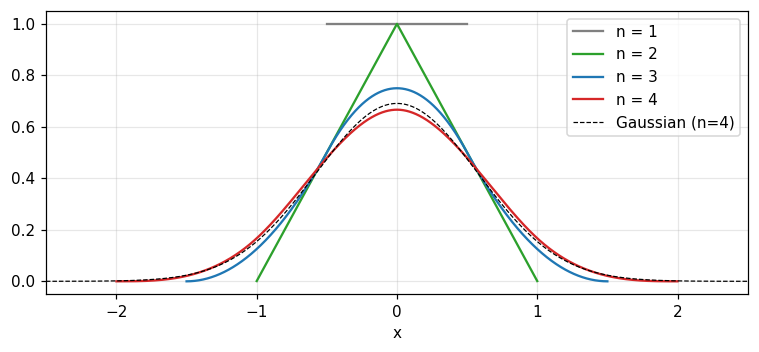

In [5]:
plt.figure(figsize=(7, 3.3))
for n, c in ((1, "gray"), (2, "tab:green"), (3, "tab:blue"), (4, "tab:red")):
    z = repeated(n); xs_ = (np.arange(len(z)) - (len(z) - 1)/2)*dxg
    plt.plot(xs_, z, color=c, label=f"n = {n}")
var = 4/12.0; xs_ = np.linspace(-2.5, 2.5, 1000)
plt.plot(xs_, np.exp(-xs_**2/(2*var))/np.sqrt(2*np.pi*var), "k--", lw=0.8, label=("Gaussian (n=4)"))
plt.xlim(-2.5, 2.5); plt.xlabel("x"); plt.legend(); plt.tight_layout(); plt.show()

#### 📤 Real output
Three repetitions, $\Pi*\Pi*\Pi$, give 0.75 at 0 and 0.125 at 1, matching the quadratic spline $3/4-x^2$ and $1/8$. $e^{-x}H(x)*\Pi$ keeps area 1 and has variance 1.0833 $=1+1/12$. The largest deviation from the equal-variance Gaussian is 0.0243 for $n=4$ and only 0.0092 for $n=8$: repeated convolution approaches a Gaussian very quickly.

## 3. Serial products: polynomial multiplication, division, the table of inverses, matrices
🎯 **What question does this method answer?** Does the serial product coincide with polynomial multiplication, are running sums and differences inverses, does serial division recover the factor, is Table 3.1 correct and does the Toeplitz matrix reproduce the convolution? Each is checked two ways.

In [6]:
from scipy.linalg import toeplitz

# Polynomial multiplication = serial product
pa, pb = np.array([2, 2, 3, 3, 4]), np.array([1, 1, 2])
assert np.array_equal(np.polymul(pa, pb), np.convolve(pa, pb))
report("len74", len(np.convolve(np.arange(1, 8), np.arange(1, 5))), "d")

# Running sums and differences
d0 = np.array([3, 1, 4, 1, 5, 9, 2, 6])
S = np.cumsum(d0)
diff_back = np.convolve(S, [1, -1])[:len(d0)]
assert np.array_equal(diff_back, d0) and np.array_equal(np.convolve(np.ones(len(d0)), d0)[:len(d0)], S)
report("run_last", S[-1], "d")

# Reciprocal sequences: {1,2,3,4,...}*{1,-2,1} and {1,-1}*{1,-1}
r1 = np.convolve(np.arange(1, 11), [1, -2, 1])[:10]
r2 = np.convolve([1, -1], [1, -1])
recip_ok = int(np.array_equal(r1, [1] + [0]*9)) + int(np.array_equal(r2, [1, -2, 1]))
assert recip_ok == 2
report("recip_ok", recip_ok, "d")

# Serial division: {1,1}*{g} = {1,3,3,1}. Method A: Bracewell's recursion; method B: polynomial division
f_, h_ = [1, 1], [1, 3, 3, 1]
g_ = []
for k in range(len(h_) - len(f_) + 1):
    g_.append((h_[k] - sum(f_[j]*g_[k - j] for j in range(1, min(k, len(f_) - 1) + 1)))/f_[0])
q_, r_ = np.polydiv(h_, f_)
assert np.allclose(g_, q_) and np.allclose(r_, 0)
report("div_g", " ".join(str(int(z)) for z in g_), "s")

# Table 3.1: check six pairs (first N terms only, as the inverses are infinite)
Nn = 12; nnn = np.arange(Nn); a_t = 0.5
pairs = [([1, 1], (-1.0)**nnn), ([1, -1], np.ones(Nn)), ([1, 0, 1], np.array([1, 0, -1, 0]*3, float)),
         ([1, 2, 1], (-1.0)**nnn*(nnn + 1)), ([1, -a_t], a_t**nnn), (np.convolve([1, -a_t], [1, -a_t]), (nnn + 1)*a_t**nnn)]
tab_ok = sum(bool(np.allclose(np.convolve(f_t, g_t)[:Nn], [1] + [0]*(Nn - 1))) for f_t, g_t in pairs)
assert tab_ok == 6
report("tab_ok", tab_ok, "d")

# Matrix form: lower-triangular Toeplitz matrix times a vector
ff, gg = np.array([2, 2, 3, 3, 4.0]), np.array([1, 1, 2.0])
L_ = len(ff) + len(gg) - 1
T = toeplitz(np.r_[ff, np.zeros(L_ - len(ff))], np.r_[ff[0], np.zeros(L_ - 1)])
toep = np.allclose(T @ np.r_[gg, np.zeros(L_ - len(gg))], np.convolve(ff, gg))
assert toep
report("toep_ok", "yes" if toep else "no", "s")

▸ len74 = 10
▸ run_last = 31
▸ recip_ok = 2
▸ div_g = 1 2 1
▸ tab_ok = 6
▸ toep_ok = yes


#### 📤 Real output
Polynomial multiplication and <code>convolve</code> agree; a 7-term with a 4-term sequence gives 10 terms. The running sum of $\{3,1,4,1,5,9,2,6\}$ ends at 31 and taking differences returns the original. 2 of 2 reciprocal pairs hold. Serial division gives $\{g\}$ = (1 2 1) by both the recursion and polynomial division. Table 3.1: 6 of 6 pairs hold. The Toeplitz matrix reproduces the convolution: yes.

## 4. Convolution by computer
🎯 **What question does this method answer?** Is Bracewell's direct code correct, what are the length modes, when does the FFT wrap around, and what does a 7-day mean do to a weekly cycle? We compare the hand code with <code>convolve</code>, count multiplications, and compare circular convolution with the FFT.

In [7]:
import math

def direct_conv(f, g):
    """Translated from Bracewell's code (p. 40)"""
    lf, lg = len(f), len(g); lh = lf + lg - 1
    h = np.zeros(lh)
    for i in range(lh):
        for j in range(max(i - lg + 1, 0), min(lf - 1, i) + 1):
            h[i] += f[j]*g[i - j]
    return h

rgc = np.random.default_rng(3)
cd = 0.0
for la, lb in ((200, 37), (5, 5)):
    fa, gb = rgc.standard_normal(la), rgc.standard_normal(lb)
    cd = max(cd, np.max(np.abs(direct_conv(fa, gb) - np.convolve(fa, gb))))
assert cd < 1e-12
report("code_diff", cd, ".1e")

x10, x4 = np.arange(10.0), np.arange(4.0)
report("len_full", len(np.convolve(x10, x4, "full")), "d"); report("len_same", len(np.convolve(x10, x4, "same")), "d")
report("len_valid", len(np.convolve(x10, x4, "valid")), "d")

# Counting multiplications (order-of-magnitude estimate)
def next_pow2(n): return 1 << (n - 1).bit_length()
lf = 10**5
for lg, tag in ((32, "short"), (2000, "long")):
    N_ = next_pow2(lf + lg - 1)
    report(f"ops_direct_{tag}", lf*lg, ",.0f")
    report("ops_fft" if tag == "short" else "ops_fft2", 3*N_*math.log2(N_), ",.0f")

# The wrap-around trap
fw, gw = rgc.standard_normal(8), rgc.standard_normal(3)
lin = np.convolve(fw, gw)
circ = np.fft.ifft(np.fft.fft(fw, 8)*np.fft.fft(gw, 8)).real
wrap = np.max(np.abs(circ - lin[:8]))                            # against the first 8 terms of the linear convolution
padded = np.fft.ifft(np.fft.fft(fw, 16)*np.fft.fft(gw, 16)).real[:10]
pad = np.max(np.abs(padded - lin))
assert wrap > 0.1 and pad < 1e-12
report("wrap_err", wrap, ".2f"); report("pad_err", pad, ".1e")

# 7-day mean on a 364-day series (circular): circular convolution versus FFT
dd = np.arange(364)
temp = 20 + 3*np.sin(2*np.pi*dd/364) + 2*np.sin(2*np.pi*dd/7)
smooth_c = np.convolve(np.pad(temp, (3, 3), mode="wrap"), np.ones(7)/7, "valid")
hker = np.zeros(364); hker[[364 - 3, 364 - 2, 364 - 1, 0, 1, 2, 3]] = 1/7
smooth_f = np.fft.ifft(np.fft.fft(temp)*np.fft.fft(hker)).real
assert np.allclose(smooth_c, smooth_f)
A_b, A_a = amplitude_spectrum(temp), amplitude_spectrum(smooth_c)
season_th = 3*abs(np.sin(7*np.pi/364)/(7*np.sin(np.pi/364)))
assert abs(A_a[1] - season_th) < 1e-9 and A_a[52] < 1e-9
report("wk_before", A_b[52], ".2f"); report("wk_after", A_a[52], ".2f")
report("season_after", A_a[1], ".4f"); report("season_th", season_th, ".4f")

▸ code_diff = 5.3e-15
▸ len_full = 13
▸ len_same = 10
▸ len_valid = 7
▸ ops_direct_short = 3,200,000
▸ ops_fft = 6,684,672
▸ ops_direct_long = 200,000,000
▸ ops_fft2 = 6,684,672
▸ wrap_err = 1.09
▸ pad_err = 4.4e-16
▸ wk_before = 2
▸ wk_after = 0
▸ season_after = 2.9982
▸ season_th = 2.9982


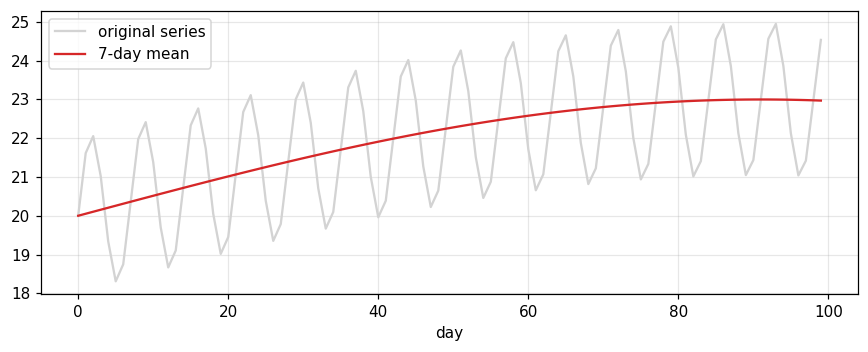

In [8]:
plt.figure(figsize=(8, 3.3))
plt.plot(dd[:100], temp[:100], color="lightgray", label=("original series"))
plt.plot(dd[:100], smooth_c[:100], "tab:red", label=("7-day mean"))
plt.xlabel(("day")); plt.legend(); plt.tight_layout(); plt.show()

#### 📤 Real output
Bracewell's hand code matches <code>convolve</code> (deviation 5.3e-15). For sequences of 10 and 4: 13, 10, 7 terms in full, same, valid modes. Multiplication counts: 3,200,000 versus about 6,684,672 for the FFT with a short filter, and 200,000,000 versus 6,684,672 with a long one. An FFT without zero-padding deviates by 1.09 (wrap-around), padded it deviates by only 4.4e-16. The 7-day mean takes the weekly amplitude from 2 to 0 and keeps the season at 2.9982 (theory 2.9982).

## 5. Autocorrelation, cross correlation, triple correlation and the energy spectrum
🎯 **What question does this method answer?** Are the chapter's autocorrelation formulas correct, is the phase really lost, does the triple correlation tell the direction of time, and is the energy spectrum equivalent to the autocorrelation? We compare numerical integrals with formulas, and direct computation with the FFT route.

In [9]:
def autocorr_tri(x):                                             # f = 1 − u on (0, 1): numerical integral
    x = abs(x)
    return integrate.quad(lambda u: (1 - u)*(1 - u - x), 0, 1 - x)[0] if x < 1 else 0.0
g_formula = lambda x: 1 - 1.5*abs(x) + 0.5*abs(x)**3
for xv in (0.0, 0.25, 0.5, 0.9):
    assert abs(autocorr_tri(xv)/autocorr_tri(0) - g_formula(xv)) < 1e-12
area_num = integrate.quad(autocorr_tri, -1, 1, points=[0])[0]
assert abs(area_num - 0.25) < 1e-9
report("g_025", g_formula(0.25), ".4f"); report("g_05", g_formula(0.5), ".4f"); report("area_ac", area_num, ".4f")

num = integrate.quad(lambda u: np.exp(-u)*np.exp(-(u + 1.0)), 0, np.inf)[0]     # e^{−x}H(x): γ(1)
assert abs(num/0.5 - np.exp(-1)) < 1e-12
report("g_exp", num/0.5, ".4f")

# Maximum at the origin, on a deterministic sequence
sig = np.sin(np.arange(200)**1.3) + 0.3*np.cos(np.arange(200)/3)
ac = np.correlate(sig, sig, "full"); mid = len(sig) - 1
ratio = np.max(np.abs(np.delete(ac, mid)))/ac[mid]
assert ratio < 1 and abs(ac[mid] - np.sum(sig**2)) < 1e-9
report("ac_ratio", ratio, ".4f")

# Three sinusoids: C(τ) is independent of the phases
tt = np.arange(1000)/1000
def three(ph):
    return 2*np.sin(2*np.pi*3*tt + ph[0]) + 1*np.sin(2*np.pi*5*tt + ph[1]) + 0.5*np.sin(2*np.pi*8*tt + ph[2])
def C_circ(v, k):                                                # normalised autocorrelation (period 1 s)
    return np.mean(v*np.roll(v, -k))/np.mean(v*v)
C_th = lambda tau: (4*np.cos(2*np.pi*3*tau) + np.cos(2*np.pi*5*tau) + 0.25*np.cos(2*np.pi*8*tau))/5.25
ph1, ph2 = (0.3, 1.1, 2.0), (2.5, 0.2, 4.0)
diffs = [abs(C_circ(three(p), k) - C_th(k/1000)) for p in (ph1, ph2) for k in (0, 50, 137, 400)]
assert max(diffs) < 1e-9
pd_ = max(abs(C_circ(three(ph1), k) - C_circ(three(ph2), k)) for k in range(0, 1000, 50))
report("c_tau", C_th(0.05), ".4f"); report("phase_diff", pd_, ".1e")

▸ g_025 = 0.6328
▸ g_05 = 0.3125
▸ area_ac = 0.25
▸ g_exp = 0.3679
▸ ac_ratio = 0.2821
▸ c_tau = 0.4093
▸ phase_diff = 2.2e-16


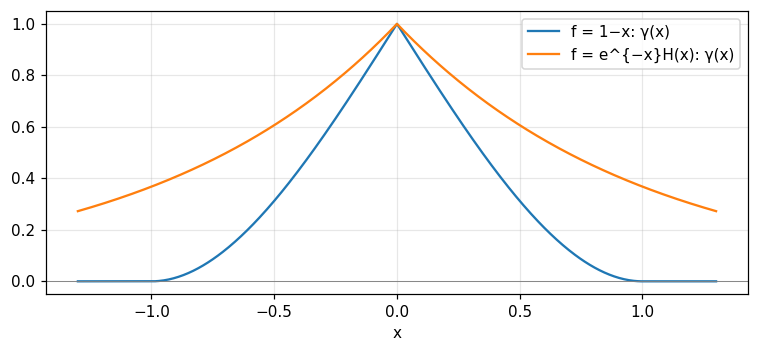

In [10]:
xs = np.linspace(-1.3, 1.3, 521)
plt.figure(figsize=(7, 3.3))
plt.plot(xs, [g_formula(x) if abs(x) < 1 else 0 for x in xs], label=("f = 1−x: γ(x)"))
plt.plot(xs, np.exp(-np.abs(xs)), label=("f = e^{−x}H(x): γ(x)"))
plt.axhline(0, color="gray", lw=0.6); plt.xlabel("x"); plt.legend(); plt.tight_layout(); plt.show()

In [11]:
# Triple correlation U(x1, x2) = Σ f(x) f(x+x1) f(x+x2). Method A: loops; method B: einsum
def triple_loops(f, m):
    n = len(f); P = np.zeros(n + 2*m); P[m:m + n] = f
    U = np.zeros((2*m + 1, 2*m + 1))
    for i, x1 in enumerate(range(-m, m + 1)):
        for j, x2 in enumerate(range(-m, m + 1)):
            U[i, j] = sum(P[m + x]*P[m + x + x1]*P[m + x + x2] for x in range(-m, n + m) if 0 <= m + x < n + 2*m and 0 <= m + x + x1 < n + 2*m and 0 <= m + x + x2 < n + 2*m)
    return U
def triple_einsum(f, m):
    n = len(f); P = np.zeros(n + 6*m); P[3*m:3*m + n] = f
    S = np.stack([np.roll(P, -s) for s in range(-m, m + 1)])
    return np.einsum("x,ix,jx->ij", P, S, S)
f123, f321 = np.array([1, 2, 3.0]), np.array([3, 2, 1.0])
U123, U321 = triple_loops(f123, 2), triple_loops(f321, 2)
assert np.allclose(U123, triple_einsum(f123, 2)) and np.allclose(U321, U123[::-1, ::-1])
assert U123[2, 2] == 36 and U123.sum() == 216 and not np.allclose(U123, U321)
assert np.allclose(np.correlate(f123, f123, "full"), np.correlate(f321, f321, "full"))
report("ac_same", "yes", "s"); report("tc_diff", "yes", "s")
report("tc_center", U123[2, 2], ".0f"); report("tc_sum", U123.sum(), ".0f")
for r in range(5):
    report(f"tc_r{r}", " ".join(f"{z:.0f}" for z in U123[r]), "s")

# Cross correlation: g⋆h(x) = h⋆g(−x), and not commutative
def xcorr(g, h):
    n = len(g); P = lambda z, k: z[k] if 0 <= k < n else 0.0
    return {x: sum(P(g, u - x)*P(h, u) for u in range(-n, 2*n)) for x in range(-(n - 1), n)}
ga, hb = np.array([1.0, 2, 4, 3]), np.array([2.0, 0, 1, 5])
c_gh, c_hg = xcorr(ga, hb), xcorr(hb, ga)
xc_ok = all(abs(c_gh[x] - c_hg[-x]) < 1e-12 for x in c_gh); xc_ne = any(abs(c_gh[x] - c_hg[x]) > 1e-9 for x in c_gh)
assert xc_ok and xc_ne
report("xc_ok", "yes", "s"); report("xc_ne", "yes", "s")

# Energy spectrum: IDFT(|X|²) = circular autocorrelation; two signals with different phases share it
v = np.sin(np.arange(64)**1.2) + 0.5
ac_direct = np.array([np.sum(v*np.roll(v, -k)) for k in range(64)])
ac_fft = np.fft.ifft(np.abs(np.fft.fft(v))**2).real
assert np.allclose(ac_direct, ac_fft)
report("wk_diff", np.max(np.abs(ac_direct - ac_fft)), ".1e")
xa, xb = three(ph1), three(ph2)
assert np.allclose(np.abs(np.fft.fft(xa)), np.abs(np.fft.fft(xb)))
report("pha_diff", np.max(np.abs(np.abs(np.fft.fft(xa))**2 - np.abs(np.fft.fft(xb))**2)), ".1e")

# Cumulative energy spectrum: a 50 Hz line plus noise
rgn = np.random.default_rng(11)
tn = np.arange(1000)/1000
yn = 3*np.sin(2*np.pi*50*tn) + rgn.normal(0, 0.5, 1000)
En = np.abs(np.fft.rfft(yn))**2; cum = np.cumsum(En)/np.sum(En)
assert abs(np.sum(En[1:500])*2/1000/1000 - np.mean(yn**2)) < 5e-2
report("cum_before", cum[49], ".3f"); report("cum_after", cum[51], ".3f"); report("cum_jump", cum[51] - cum[49], ".3f")

# The pulse sequence {1100101}
pj = np.array([1, 1, 0, 0, 1, 0, 1.0])
lin_ac = np.correlate(pj, pj, "full")
circ_ac = np.array([np.sum(pj*np.roll(pj, -k)) for k in range(7)])
assert lin_ac[6] == 4 and np.all(circ_ac[1:] == 2)
report("ac_peak", lin_ac[6], ".0f"); report("ac_side", np.max(np.delete(lin_ac, 6)), ".0f"); report("ac_circ", circ_ac[1], ".0f")

▸ ac_same = yes
▸ tc_diff = yes
▸ tc_center = 36
▸ tc_sum = 216
▸ tc_r0 = 3 6 9 0 0
▸ tc_r1 = 6 14 22 6 0
▸ tc_r2 = 9 22 36 14 3
▸ tc_r3 = 0 6 14 22 6
▸ tc_r4 = 0 0 3 6 9
▸ xc_ok = yes
▸ xc_ne = yes
▸ wk_diff = 7.1e-15
▸ pha_diff = 2.3e-10
▸ cum_before = 0.005
▸ cum_after = 0.951
▸ cum_jump = 0.946
▸ ac_peak = 4
▸ ac_side = 1
▸ ac_circ = 2


#### 📤 Real output
For $f=1-x$: $\gamma(0.25)$ = 0.6328, $\gamma(0.5)$ = 0.3125, numerator area 0.25; for $e^{-x}H(x)$: $\gamma(1)$ = 0.3679. The autocorrelation never exceeds its peak (side ratio 0.2821). For three waves, $C(0.05)$ = 0.4093 and is independent of the phases (difference 2.2e-16). The triple correlation of $\{1,2,3\}$ has centre 36, sum 216, and differs from that of $\{3,2,1\} although the two autocorrelations are identical (yes). Cross correlation satisfies $g\star h(x)=h\star g(-x)$ (yes) but is not commutative (yes). The inverse transform of $|X|^2$ equals the circular autocorrelation (deviation 7.1e-15), and two signals with different phases share the energy spectrum (deviation 2.3e-10). The cumulative spectrum jumps by 0.946 at the 50 Hz line. The sequence $\{1100101\}$ has peak 4, side value 1 and circular autocorrelation 2.